# MNIST digit classification with a multi-layer perceptron

Kaggle [digit-recognizer](https://www.kaggle.com/competitions/digit-recognizer):
42,000 labelled 28x28 images of the digits 0-9. Each row is one image, 784 pixel
columns plus a label.

The code lives in `src/` and is covered by the test suite. The cells here call it
and plot what comes back.

| | Section |
|---|---|
| 1 | Data and cleaning |
| 2 | Train, validation and test split |
| 3 | Baseline model |
| 4 | Hyperparameter study |
| 5 | Confirmation run |
| 6 | Test-set evaluation |
| 7 | The same model in PyTorch Lightning |
| 8 | Improvements beyond the baseline |
| 9 | Limitations and further work |

Two conventions hold throughout. Nothing is ever *selected* on the test split:
every choice -- hyperparameters, epoch, checkpoint -- is made on validation, and
the test rows are read only to score what validation had already picked, in
sections 6 and 8. And every sweep number in a full run is a mean over three
seeds, reported with the spread beside it.

## Running on a GPU

Section 4 trains 132 models: about 45 minutes on a Colab T4, an hour and a half
on an Apple-silicon laptop.

Upload the whole project, not just this notebook -- every cell imports from
`src/`. `make bundle` builds the zip; the README's *Running on a cloud GPU*
section has the Colab and Kaggle details.

The next three cells unpack it, install whatever the image is missing, and pick
the device; they do nothing locally or on a second run. The third sets `QUICK`,
which shortens every epoch budget so *Run all* finishes in minutes. The hardware
decides it, and `MNIST_MLP_QUICK=0` forces the full study.


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#%matplotlib inline
#import matplotlib
#print(matplotlib.get_backend())

In [ ]:
#from IPython.display import Image, display
#from pathlib import Path
#for png in sorted(Path("reports/figures").glob("*.png")):
#    print(png.name); display(Image(str(png)))

In [4]:
from google.colab import files
import zipfile, pathlib
uploaded = files.upload()                    # opens a file picker
name = next(iter(uploaded))
zipfile.ZipFile(name).extractall("/content/bidanu-NLP.AI.1.5")
print(sorted(p.name for p in pathlib.Path("/content/bidanu-NLP.AI.1.5").iterdir()))

Saving bidanu-NLP.AI.1.5.zip to bidanu-NLP.AI.1.5.zip
['.github', '.gitignore', '.python-version', '4A15.md', 'Makefile', 'Mathematical_theoretical_analysis.md', 'README.md', 'data', 'notebooks', 'pyproject.toml', 'reports', 'src', 'tests', 'uv.lock']


In [5]:
# Unpack an uploaded `make bundle` zip into a directory of its own. The
# archive has no wrapping folder, so extracting it in place scatters files.
# No-op locally, on an already-extracted zip, and on a second run.
import zipfile
from pathlib import Path

UPLOAD_DIRS = (Path("/content"), Path("/kaggle/working"), Path("/kaggle/input"))


def holds_the_project(archive: Path) -> bool:
    """Whether a zip is this project rather than some other upload."""
    try:
        with zipfile.ZipFile(archive) as bundle:
            return any(name.endswith("src/utils.py") for name in bundle.namelist())
    except zipfile.BadZipFile:
        return False


bundles = [
    candidate
    for base in UPLOAD_DIRS
    if base.is_dir()
    for candidate in sorted((*base.glob("*.zip"), *base.glob("*/*.zip")))
    if holds_the_project(candidate)
]

if not bundles:
    print("no bundle to unpack: running locally, or the code is already here")
else:
    archive = bundles[0]
    # /kaggle/input is read-only; the run writes reports.
    writable = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path("/content")
    target = writable / archive.stem
    if (target / "src" / "utils.py").is_file():
        print("already unpacked:", target)
    else:
        with zipfile.ZipFile(archive) as bundle:
            bundle.extractall(target)
        print("unpacked", archive.name, "->", target)
    print("  holds:", ", ".join(sorted(entry.name for entry in target.iterdir())[:8]), "...")

already unpacked: /content/bidanu-NLP.AI.1.5
  holds: .github, .gitignore, .python-version, 4A15.md, Makefile, Mathematical_theoretical_analysis.md, README.md, data ...


In [6]:
# Find the project and make `import src` work. Locally this only walks up
# from the working directory and chdirs; the cloud paths below are skipped.
import os
import sys
from pathlib import Path

PROJECT_NAME = "bidanu-NLP.AI.1.5"
REPO = "TuringCollegeSubmissions/bidanu-NLP.AI.1.5"
EXTRAS = ("lightning", "torchmetrics", "tabulate")

# `google.colab` imports on the Kaggle image too, so read the environment.
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or "KAGGLE_URL_BASE" in os.environ
IN_COLAB = not IN_KAGGLE and bool({"COLAB_RELEASE_TAG", "COLAB_GPU"} & set(os.environ))
PLATFORM = "kaggle" if IN_KAGGLE else "colab" if IN_COLAB else "local"


def find_project(name: str) -> Path | None:
    """Return the directory that holds this project's `src/`.

    Walks up from the working directory first; the cloud mounts, which are
    slow to glob, are searched only if that fails.
    """
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / "src" / "utils.py").is_file():
            return path
    if PLATFORM == "local":
        return None
    for base in (Path("/content"), Path("/kaggle/working"), Path("/kaggle/input")):
        if not base.is_dir():
            continue
        for path in (base, base / name, *base.glob("*"), *base.glob("*/*")):
            if (path / "src" / "utils.py").is_file():
                return path
    return None


project = find_project(PROJECT_NAME)

if project is None and PLATFORM == "local":
    raise RuntimeError(
        "No src/utils.py above this notebook. Start jupyter from inside the "
        "project folder: `make notebook`, or `jupyter lab` from the project root."
    )

if project is None:
    # Cloud only. The clone carries data/raw/train.csv.gz, so the data
    # arrives with the code.
    import subprocess

    def github_token() -> str | None:
        """Read a token from the platform's secret store. Never printed."""
        if token := os.environ.get("GITHUB_TOKEN", ""):
            return token
        try:
            from google.colab import userdata

            return userdata.get("GITHUB_TOKEN")
        except Exception:
            pass
        try:
            from kaggle_secrets import UserSecretsClient

            return UserSecretsClient().get_secret("GITHUB_TOKEN")
        except Exception:
            return None

    where = Path("/kaggle/working") if IN_KAGGLE else Path("/content")
    target = (where if where.is_dir() else Path.cwd()) / PROJECT_NAME
    token = github_token()
    url = f"https://{token}@github.com/{REPO}.git" if token else f"https://github.com/{REPO}.git"

    print(f"[{PLATFORM}] the project is not here yet, cloning {REPO}")
    done = subprocess.run(
        ["git", "clone", "--depth", "1", url, str(target)], capture_output=True, text=True
    )
    if done.returncode == 0:
        project = target
    else:
        # git echoes the URL it was given, so scrub the token.
        reason = (done.stderr or "").replace(token, "***") if token else (done.stderr or "")
        print("  clone failed:", reason.strip().splitlines()[-1] if reason.strip() else "?")
        if not token:
            print(f"  {REPO} is private, and no GITHUB_TOKEN was found.")
            print("  Colab: key icon, left sidebar. Kaggle: Add-ons, Secrets.")
        print("\n  Or upload the code: run `make bundle` locally for a 14 MB zip,")
        print("  then drop it in (Colab: Files pane; Kaggle: +Add Input, Datasets)")
        print("  and run the unpack cell above before this one.")
        raise RuntimeError(
            f"{PROJECT_NAME} is not on this machine. Follow the steps printed above, "
            "then run this cell again before running anything else."
        )

# /kaggle/input is read-only; the run writes reports, figures and checkpoints.
if Path("/kaggle/input") in project.parents:
    import shutil

    writable = Path("/kaggle/working") / project.name
    if not writable.exists():
        shutil.copytree(project, writable, ignore=shutil.ignore_patterns(".git", "__pycache__"))
    project = writable

os.chdir(project)
if str(project) not in sys.path:
    sys.path.insert(0, str(project))

if PLATFORM != "local":
    # Install only what is missing. torch is never touched: pip would swap
    # the CUDA build for a CPU one.
    import importlib.util
    import subprocess

    missing = [name for name in EXTRAS if importlib.util.find_spec(name) is None]
    if missing:
        print("installing", " ".join(missing))
        if subprocess.run([sys.executable, "-m", "pip", "-q", "install", *missing]).returncode:
            print("\npip could not reach the network.")
            print("On Kaggle: Settings, Internet, on -- it is off by default.")
            print("Only section 7 needs lightning; every other section runs without it.")

# Kaggle can mount the competition read-only. Everywhere else the data comes
# from the committed data/raw/train.csv.gz, which load_raw_train falls back to.
COMPETITION_CSV = Path("/kaggle/input/digit-recognizer/train.csv")
CSV_PATH = COMPETITION_CSV if COMPETITION_CSV.is_file() else None

LOCAL_CSV = Path("data/raw/train.csv")
SOURCE = CSV_PATH or (LOCAL_CSV if LOCAL_CSV.is_file() else Path("data/raw/train.csv.gz"))
print(f"{PLATFORM} | {Path.cwd()} | data from {SOURCE}")

installing lightning torchmetrics
colab | /content/bidanu-NLP.AI.1.5 | data from data/raw/train.csv.gz


In [7]:
import os
from dataclasses import replace

import matplotlib.pyplot as plt
import pandas as pd

from src.config import ConvConfig, DataConfig, ExperimentConfig, ModelConfig, TrainConfig
from src.data import build_splits, clean, load_raw_train, make_loaders
from src.ensemble import (
    accuracy,
    average_probabilities,
    model_probabilities,
    train_ensemble,
    tta_probabilities,
)
from src.evaluate import evaluate_run
from src.experiments import (
    BASELINE,
    FACTORS,
    QUICK_FACTORS,
    best_levels,
    configuration_from,
    run_sweep,
    summarise,
    sweep_paths,
    write_summary,
)
from src.models import build_model, count_parameters
from src.reference_cnn import test_accuracy, train_cnn
from src.train import save_run, train_from_splits
from src.utils import (
    FIGURES,
    describe_device,
    full_study_is_affordable,
    select_device,
)

# Draw figures into the notebook. This goes after the imports: a module that
# calls matplotlib.use() at import time would override an earlier choice.
%matplotlib inline

DEVICE = select_device("auto")
print("training on", describe_device(DEVICE))

# One switch for the whole notebook. QUICK shortens every budget so Run all
# finishes in minutes; a CUDA GPU turns it off, which is what the reported
# numbers need.
#
# The hardware decides unless MNIST_MLP_QUICK says otherwise: set it to 0 to
# force the full study on a machine the check rules out, or to 1 to force the
# short one. A headless `nbconvert --execute` run asks for the full study that
# way, without editing this cell.
_forced = os.environ.get('MNIST_MLP_QUICK')
QUICK = _forced not in {'0', 'false'} if _forced is not None else not full_study_is_affordable()

# Epoch ceilings, not targets: the weights kept are those of the best
# validation epoch, so a higher ceiling costs time and cannot cost accuracy.
MAX_EPOCHS = 8 if QUICK else 100       # baseline, and every run in the sweep
FINAL_EPOCHS = 12 if QUICK else 150    # the confirmation run
ENSEMBLE_EPOCHS = 6 if QUICK else 100  # each ensemble member, and the CNN

# What ends a run is patience: early stopping fires once the validation loss
# has gone that many epochs without a new minimum.
#
# The sweep keeps it, so its runs stop by the same rule and stay comparable.
# The six runs whose numbers are quoted switch it off: a training curve only
# shows the overfitting turn if the run reaches it, and cosine and one-cycle
# anneal over the whole of max_epochs.
SWEEP_PATIENCE = 10
FULL_PATIENCE = FINAL_EPOCHS  # above every budget here, so it never trips

# Two levels per factor and one seed is 20 runs; 44 levels and three seeds is
# 132. The spread over seeds is what separates an effect from noise.
SWEEP_FACTORS = QUICK_FACTORS if QUICK else FACTORS
SWEEP_SEEDS = [0] if QUICK else [0, 1, 2]
SWEEP_RUNS = sum(len(levels) for levels in SWEEP_FACTORS.values()) * len(SWEEP_SEEDS)

# A quick run writes beside a full one rather than over it. Same names the
# command line uses.
RUN_NAME = 'final-quick' if QUICK else 'final'
SWEEP_CSV, SWEEP_SUMMARY = sweep_paths(QUICK)

print('quick run' if QUICK else 'full run', '| epochs',
      (MAX_EPOCHS, FINAL_EPOCHS, ENSEMBLE_EPOCHS),
      f'| patience {SWEEP_PATIENCE} in the sweep, none in the reported runs',
      f'| sweep {SWEEP_RUNS} runs | writing', RUN_NAME)

training on cuda (Tesla T4)
full run | epochs (100, 150, 100) | patience 10 in the sweep, none in the reported runs | sweep 132 runs | writing final


## 1. Data and cleaning

`train.csv` has 42,000 rows: a `label` column and 784 pixel columns, each an
integer in $[0, 255]$.

The competition also ships `test.csv`, but it carries no labels and can only be
scored by the leaderboard, so nothing here uses it. The 20% held out in
section 2 serves that purpose instead.

In [8]:
frame = load_raw_train(CSV_PATH)
print(frame.shape)
frame.head(3).iloc[:, :8]

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6
0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0


In [9]:
cleaned, report = clean(frame)
print(report.summary())

rows in                   42,000
  missing values               0
  out of range                 0
  duplicate images             0
  label conflicts              0
  constant images              0
rows out                  42,000  (0 removed)


`clean` removes five kinds of row:

| Removed | Reason |
|---|---|
| Missing values | Not a pixel value |
| Pixels outside $[0, 255]$, labels outside $0..9$ | Corrupt |
| Repeated images, same label | Redundant, one copy is kept |
| Repeated images, different labels | Contradictory, every copy is dropped |
| Constant images | No signal |

Cleaning runs before the split, so no repeated image can straddle it.

### Class balance and pixel intensities

Class counts, and where the ink sits in the frame.

smallest class: 3795  largest: 4684


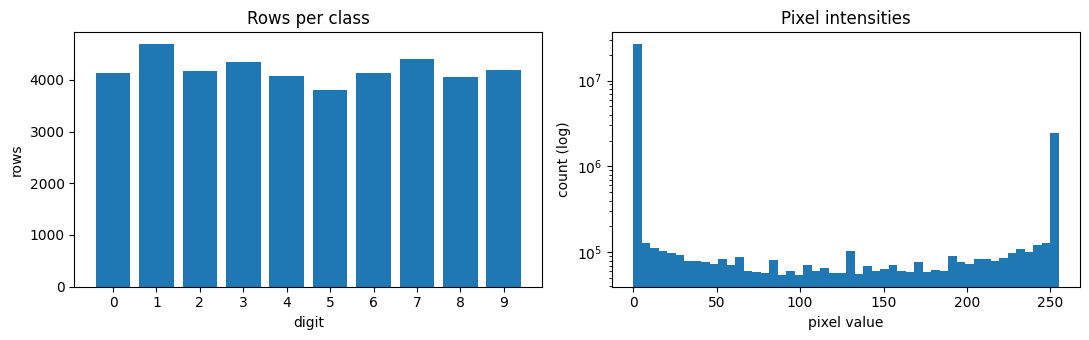

In [10]:
counts = cleaned['label'].value_counts().sort_index()

figure, (balance, intensity) = plt.subplots(1, 2, figsize=(11, 3.5))
balance.bar(counts.index, counts.to_numpy())
balance.set_xticks(range(10))
balance.set_xlabel('digit'); balance.set_ylabel('rows')
balance.set_title('Rows per class')

intensity.hist(cleaned.drop(columns='label').to_numpy().ravel(), bins=50)
intensity.set_yscale('log')
intensity.set_xlabel('pixel value'); intensity.set_ylabel('count (log)')
intensity.set_title('Pixel intensities')
figure.tight_layout()

print('smallest class:', counts.min(), ' largest:', counts.max())
plt.show()


The classes sit within a few percent of each other, so accuracy is a fair
headline metric and no class weighting is needed. The test report computes macro
F1 as well.

The intensity histogram uses a log scale. Most pixels are background, and the
ink covers a small, fairly consistent part of a centred, size-normalised frame.

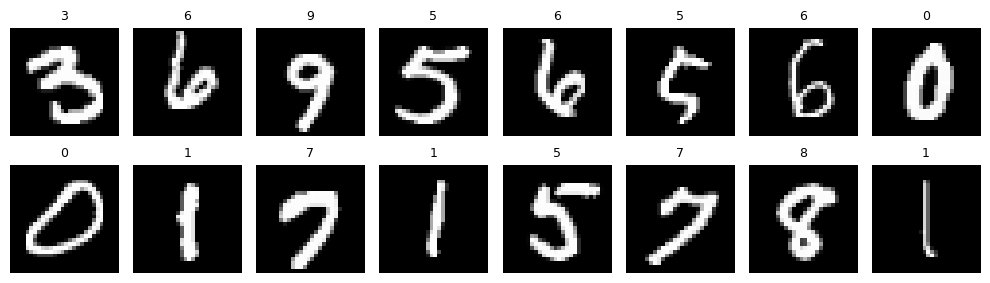

In [11]:
figure, axes = plt.subplots(2, 8, figsize=(10, 3))
for axis, (_, row) in zip(axes.ravel(), cleaned.sample(16, random_state=0).iterrows()):
    axis.imshow(row.drop('label').to_numpy().reshape(28, 28), cmap='gray')
    axis.set_title(int(row['label']), fontsize=9)
    axis.axis('off')
figure.tight_layout()
plt.show()


## 2. Train, validation and test split

60 / 20 / 20, stratified on the label so each split keeps the class proportions,
and seeded so every model in this notebook sees the same partition. The test
split is not touched again until section 6.

Pixels are scaled to $[0,1]$ and then standardised with the mean and standard
deviation of the training split alone.

In [12]:
data_config = DataConfig(train_fraction=0.6, val_fraction=0.2, seed=42)
splits = build_splits(cleaned, data_config)

print(splits.sizes)
print(f"train pixel mean {splits.mean:.4f}, std {splits.std:.4f}")
splits.class_counts()

{'train': 25200, 'val': 8400, 'test': 8400}
train pixel mean 0.1311, std 0.3087


,train,val,test
digit,,,
0,2479,827,826
1,2810,937,937
2,2506,836,835
3,2611,870,870
4,2443,814,815
5,2277,759,759
6,2482,827,828
7,2641,880,880
8,2438,812,813


## 3. Baseline model

Hidden layers of 512 and 256 units, ReLU, batch normalisation, dropout 0.2,
AdamW at $10^{-3}$, batch size 128, cross-entropy. Nothing is tuned. This is the
fixed reference every later change is measured against.

The network outputs logits and `CrossEntropyLoss` applies the softmax itself.

In [13]:
baseline = ExperimentConfig(
    name='baseline',
    data=data_config,
    model=ModelConfig(hidden_sizes=(512, 256), activation='relu', dropout=0.2, batch_norm=True),
    train=TrainConfig(optimizer='adamw', learning_rate=1e-3, batch_size=128, max_epochs=MAX_EPOCHS, patience=FULL_PATIENCE),
)

baseline_result = train_from_splits(splits, baseline, verbose=True)
print(f'\nbest val accuracy {baseline_result.best_val_accuracy:.4f} at epoch {baseline_result.best_epoch}')

epoch   1  train loss 0.3420  acc 0.8964  |  val loss 0.1545  acc 0.9532
epoch   2  train loss 0.1412  acc 0.9579  |  val loss 0.1209  acc 0.9636
epoch   3  train loss 0.0979  acc 0.9702  |  val loss 0.1071  acc 0.9661
epoch   4  train loss 0.0756  acc 0.9767  |  val loss 0.1025  acc 0.9692
epoch   5  train loss 0.0584  acc 0.9814  |  val loss 0.1033  acc 0.9688
epoch   6  train loss 0.0459  acc 0.9852  |  val loss 0.0914  acc 0.9727
epoch   7  train loss 0.0384  acc 0.9883  |  val loss 0.0995  acc 0.9706
epoch   8  train loss 0.0331  acc 0.9892  |  val loss 0.1025  acc 0.9706
epoch   9  train loss 0.0318  acc 0.9898  |  val loss 0.0948  acc 0.9731
epoch  10  train loss 0.0269  acc 0.9909  |  val loss 0.1066  acc 0.9714
epoch  11  train loss 0.0258  acc 0.9913  |  val loss 0.1005  acc 0.9724
epoch  12  train loss 0.0210  acc 0.9935  |  val loss 0.1015  acc 0.9738
epoch  13  train loss 0.0210  acc 0.9933  |  val loss 0.0964  acc 0.9750
epoch  14  train loss 0.0172  acc 0.9942  |  val lo

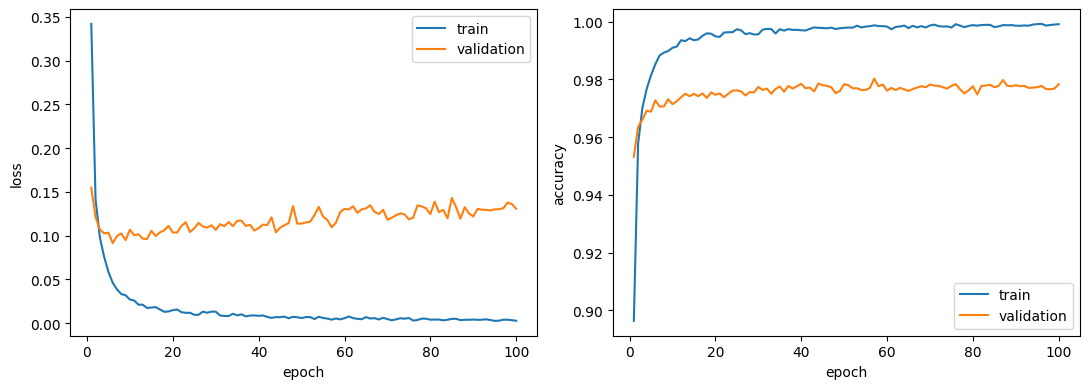

In [14]:
history = baseline_result.history_frame()

figure, (loss_axis, accuracy_axis) = plt.subplots(1, 2, figsize=(11, 4))
loss_axis.plot(history['epoch'], history['train_loss'], label='train')
loss_axis.plot(history['epoch'], history['val_loss'], label='validation')
loss_axis.set_xlabel('epoch'); loss_axis.set_ylabel('loss'); loss_axis.legend()
accuracy_axis.plot(history['epoch'], history['train_accuracy'], label='train')
accuracy_axis.plot(history['epoch'], history['val_accuracy'], label='validation')
accuracy_axis.set_xlabel('epoch'); accuracy_axis.set_ylabel('accuracy'); accuracy_axis.legend()
figure.tight_layout()
plt.show()


### Gradient norms by layer

The training loop records the L2 norm of each weight matrix's gradient every
epoch, so depth-related trouble can be read layer by layer instead of guessed at
from a flat loss curve.

The baseline uses ReLU, Kaiming initialisation and batch normalisation, so the
norms should stay comparable across layers. The sigmoid level and the deeper
hidden stacks in section 4 are the contrast.

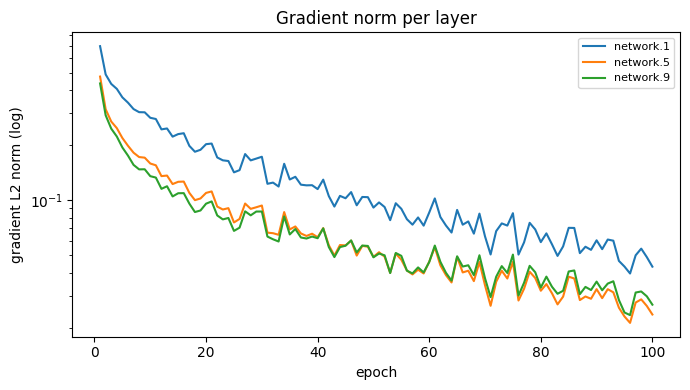

In [15]:
norm_columns = [column for column in history.columns if column.startswith('grad_norm/')]

figure, axis = plt.subplots(figsize=(7, 4))
for column in norm_columns:
    axis.plot(history['epoch'], history[column], label=column.split('/')[-1])
axis.set_yscale('log')
axis.set_xlabel('epoch'); axis.set_ylabel('gradient L2 norm (log)')
axis.set_title('Gradient norm per layer')
axis.legend(fontsize=8)
figure.tight_layout()
plt.show()


## 4. Hyperparameter study

Optimizers, learning rates, batch sizes, activations, dropout ratios, hidden
architectures and loss functions, plus learning-rate schedule, weight decay and
augmentation.

Ten factors, 44 levels, three seeds each: 132 runs. Each level is varied alone
from the baseline, which makes this a screening design rather than a grid, and
each is reported as mean ± standard deviation over the seeds.

This is the expensive cell, roughly an hour on a T4. On CPU, run
`python -m src.experiments --quick` instead; that is a pipeline check and its
numbers are not reportable.

In [16]:
# Only the epoch budget and the patience differ from BASELINE, so every level
# is trained and stopped by the same rule.
sweep_baseline = replace(
    BASELINE,
    train=replace(BASELINE.train, max_epochs=MAX_EPOCHS, patience=SWEEP_PATIENCE),
)

results = run_sweep(
    splits, SWEEP_FACTORS, sweep_baseline, SWEEP_SEEDS, output_path=SWEEP_CSV, verbose=True
)
print(f"{len(results)} runs over {results['factor'].nunique()} factors")
results.head()

[  1/132] optimizer=sgd seed=0  val acc 0.9349  (70.4s)
[  2/132] optimizer=sgd seed=1  val acc 0.9374  (70.2s)
[  3/132] optimizer=sgd seed=2  val acc 0.9365  (70.6s)
[  4/132] optimizer=sgd_momentum seed=0  val acc 0.9692  (71.9s)
[  5/132] optimizer=sgd_momentum seed=1  val acc 0.9705  (70.9s)
[  6/132] optimizer=sgd_momentum seed=2  val acc 0.9705  (71.1s)
[  7/132] optimizer=adam seed=0  val acc 0.9752  (14.6s)
[  8/132] optimizer=adam seed=1  val acc 0.9782  (24.8s)
[  9/132] optimizer=adam seed=2  val acc 0.9760  (15.8s)
[ 10/132] optimizer=adamw seed=0  val acc 0.9742  (11.2s)
[ 11/132] optimizer=adamw seed=1  val acc 0.9755  (11.9s)
[ 12/132] optimizer=adamw seed=2  val acc 0.9750  (12.9s)
[ 13/132] optimizer=rmsprop seed=0  val acc 0.9688  (23.9s)
[ 14/132] optimizer=rmsprop seed=1  val acc 0.9685  (18.8s)
[ 15/132] optimizer=rmsprop seed=2  val acc 0.9690  (18.9s)
[ 16/132] learning_rate=0.0001 seed=0  val acc 0.9745  (36.6s)
[ 17/132] learning_rate=0.0001 seed=1  val acc 0.

,factor,level,seed,val_accuracy,train_accuracy,val_loss,best_epoch,epochs_run,n_parameters,seconds,stopped_early,error
0,optimizer,sgd,0,0.934881,0.924881,0.217340,98,100,537354,70.4,False,
1,optimizer,sgd,1,0.937381,0.924802,0.216882,99,100,537354,70.2,False,
2,optimizer,sgd,2,0.936548,0.924048,0.215229,100,100,537354,70.6,False,
3,optimizer,sgd_momentum,0,0.969167,0.984127,0.101756,98,100,537354,71.9,False,
4,optimizer,sgd_momentum,1,0.970476,0.985556,0.099255,100,100,537354,70.9,False,


In [17]:
summary = summarise(results)
write_summary(summary, SWEEP_SUMMARY)
summary.round(4)

,factor,level,val_accuracy_mean,val_accuracy_std,n_runs,mean_epochs,mean_seconds,n_parameters,best_of_factor
0,optimizer,sgd,0.9363,0.0013,3,100.0000,70.4000,537354,False
1,optimizer,sgd_momentum,0.9700,0.0008,3,100.0000,71.3000,537354,False
2,optimizer,adam,0.9765,0.0016,3,24.3333,18.4000,537354,True
3,optimizer,adamw,0.9749,0.0007,3,16.0000,12.0000,537354,False
4,optimizer,rmsprop,0.9688,0.0003,3,27.3333,20.5333,537354,False
5,learning_rate,0.0001,0.9743,0.0002,3,43.6667,32.6667,537354,False
6,learning_rate,0.0003,0.9752,0.0015,3,27.6667,20.6333,537354,False
7,learning_rate,0.001,0.9749,0.0007,3,16.0000,11.9333,537354,False
8,learning_rate,0.003,0.9764,0.0003,3,18.6667,14.0000,537354,True
9,learning_rate,0.01,0.9754,0.0022,3,16.3333,12.3000,537354,False


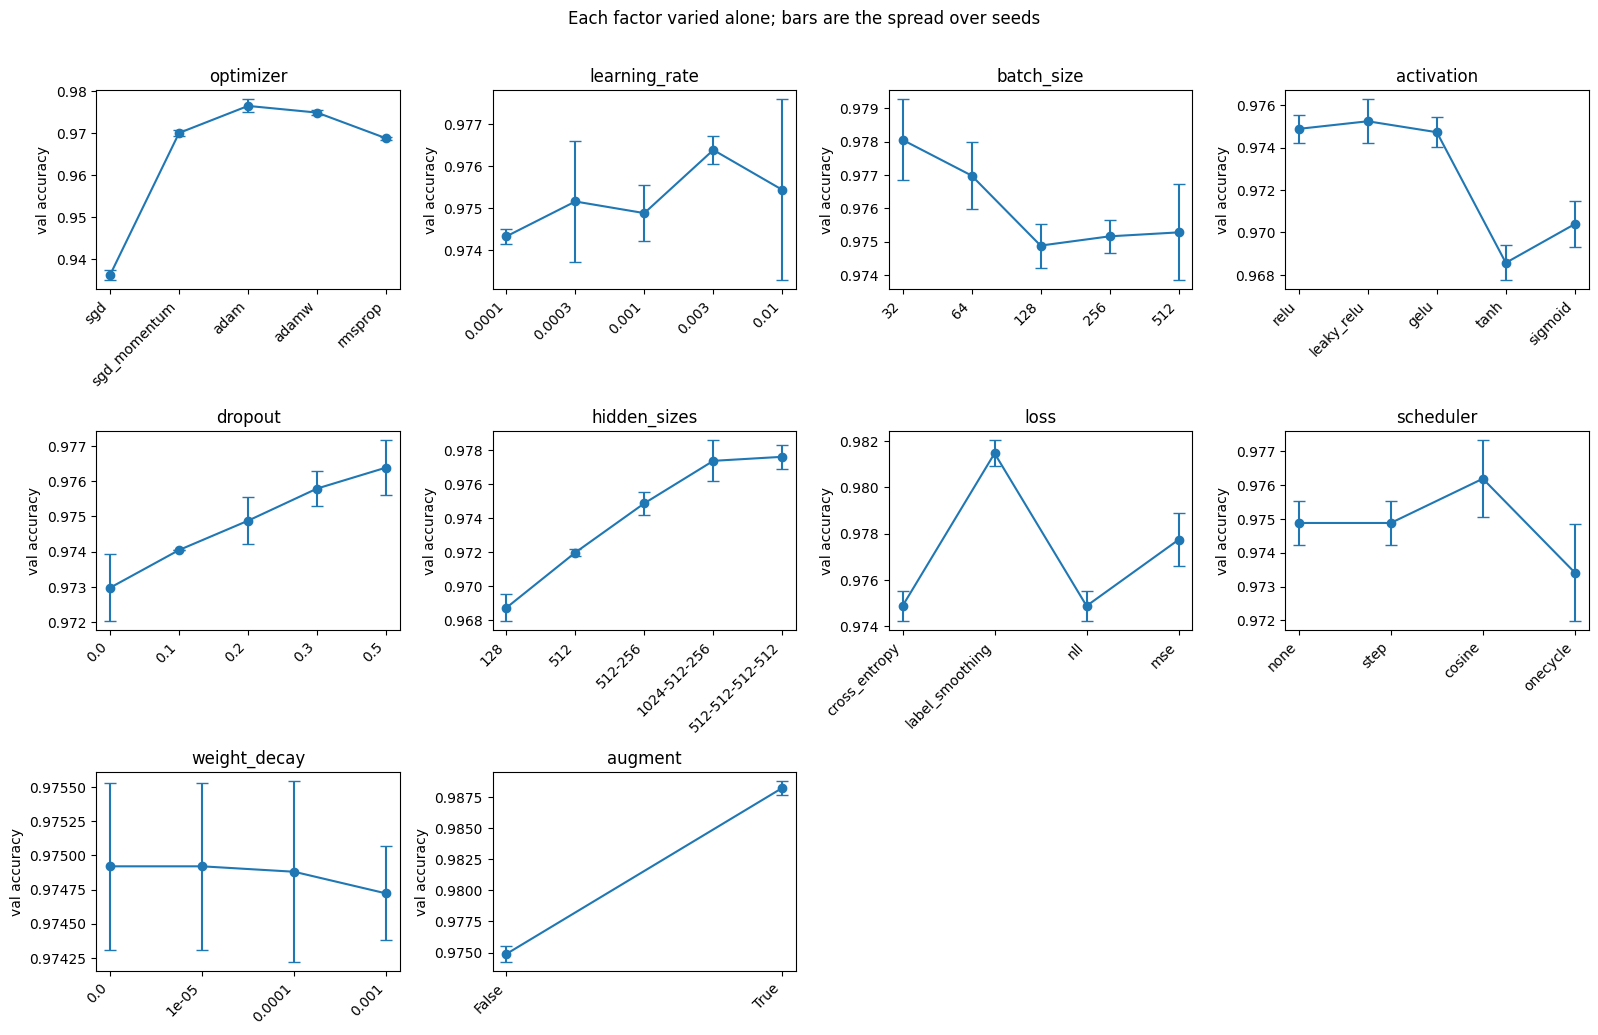

In [18]:
# One panel per factor, sized to the number of factors so none is dropped.
factors = list(summary["factor"].unique())
columns = 4
rows = -(-len(factors) // columns)

figure, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.4 * rows), squeeze=False)
flat = axes.ravel()

for axis, factor in zip(flat, factors, strict=False):
    block = summary[summary["factor"] == factor]
    axis.errorbar(
        range(len(block)),
        block["val_accuracy_mean"],
        yerr=block["val_accuracy_std"],
        marker="o",
        capsize=4,
    )
    axis.set_xticks(range(len(block)), labels=block["level"], rotation=45, ha="right")
    axis.set_title(factor)
    axis.set_ylabel("val accuracy")

for axis in flat[len(factors):]:
    axis.axis("off")

figure.suptitle("Each factor varied alone; bars are the spread over seeds", y=1.01)
figure.tight_layout()
plt.show()


### Reading the results

A factor matters when the gap between its best and worst level clears the error
bars in the panel above. A gap smaller than the seed-to-seed spread is not a
result.

Two couplings this design cannot show, because it varies one factor at a time:

- The learning rate does not transport across optimizers. Read the optimizer and
  learning-rate rows together rather than separately.
- The useful learning rate grows with the batch size.

One more caveat belongs to the `scheduler` row. Every schedule anneals over the
whole of `max_epochs`, and the sweep keeps early stopping on, so a run that
stopped early was scored part way through its schedule. That row compares
schedules at a disadvantage to `none`.

## 5. Confirmation run

Varying one factor at a time measures each against a fixed baseline, so it
cannot see interactions. Combining the winning levels is a hypothesis, and this
run tests it on validation.

The levels come from the summary table rather than by hand. Early stopping is
off here, so whichever schedule won anneals fully. If the combination lands
below the best single-factor run, that is a result too: the factors interact.

In [ ]:
winners = best_levels(summary, SWEEP_FACTORS)
for factor, level in winners.items():
    print(f'{factor:>14}  {level}')

chosen = configuration_from(winners, baseline)
final = replace(
    chosen,
    name=RUN_NAME,
    train=replace(chosen.train, max_epochs=FINAL_EPOCHS, patience=FULL_PATIENCE),
)

final_result = train_from_splits(splits, final, verbose=True)
print(f'\nvalidation accuracy {final_result.best_val_accuracy:.4f}')
print('saved to', save_run(final_result, final))

     optimizer  adam
 learning_rate  0.003
    batch_size  32
    activation  leaky_relu
       dropout  0.5
  hidden_sizes  (512, 512, 512, 512)
          loss  label_smoothing
     scheduler  cosine
  weight_decay  0.0
       augment  True
epoch   1  train loss 1.2902  acc 0.6919  |  val loss 0.7005  acc 0.9329
epoch   2  train loss 0.9726  acc 0.8229  |  val loss 0.6584  acc 0.9444
epoch   3  train loss 0.8858  acc 0.8585  |  val loss 0.6230  acc 0.9607
epoch   4  train loss 0.8502  acc 0.8731  |  val loss 0.6079  acc 0.9619
epoch   5  train loss 0.8291  acc 0.8792  |  val loss 0.6029  acc 0.9646
epoch   6  train loss 0.8124  acc 0.8874  |  val loss 0.5914  acc 0.9688
epoch   7  train loss 0.7914  acc 0.8971  |  val loss 0.5886  acc 0.9675
epoch   8  train loss 0.7833  acc 0.9008  |  val loss 0.5865  acc 0.9700
epoch   9  train loss 0.7664  acc 0.9057  |  val loss 0.5736  acc 0.9752
epoch  10  train loss 0.7553  acc 0.9101  |  val loss 0.5770  acc 0.9750
epoch  11  train loss 0.7571

## 6. Test-set evaluation

Every choice so far was made on validation. This is the first and only read of
the test split.

In [ ]:
payload = evaluate_run(RUN_NAME, CSV_PATH)

print(f"test accuracy {payload['accuracy']:.4f} on {payload['n_test']:,} rows")
print(f"macro F1 {payload['macro_f1']:.4f}")
print(f"expected calibration error {payload['ece']:.4f}")
payload['per_class']

test accuracy 0.9856 on 8,400 rows
macro F1 0.9855
expected calibration error 0.0787


,precision,recall,f1-score,support
0,0.9939,0.9903,0.9921,826.0000
1,0.9904,0.9883,0.9893,937.0000
2,0.9741,0.9916,0.9828,835.0000
3,0.9908,0.9885,0.9896,870.0000
4,0.9793,0.9890,0.9841,815.0000
5,0.9777,0.9842,0.9810,759.0000
6,0.9810,0.9952,0.9880,828.0000
7,0.9931,0.9875,0.9903,880.0000
8,0.9887,0.9705,0.9795,813.0000
9,0.9854,0.9701,0.9777,837.0000


In [ ]:
payload['confusion']

predicted,0,1,2,3,4,5,6,7,8,9
true,,,,,,,,,,
0,818,0,1,0,1,0,5,0,1,0
1,0,926,5,1,0,1,0,1,3,0
2,1,2,828,1,2,0,0,0,1,0
3,0,1,3,860,0,5,0,1,0,0
4,0,0,0,0,806,0,2,0,0,7
5,0,0,2,2,0,747,5,0,2,1
6,2,0,0,0,0,2,824,0,0,0
7,0,1,5,0,3,1,0,869,0,1
8,1,3,5,0,2,5,4,1,789,3


The off-diagonal entries are the pairs a person also hesitates over: 4 and 9
first by a clear margin, 16 of them between the two directions, then 3 and 5,
1 and 2, and 0 and 6 at seven each. No pair reaches a sixth of the 121 errors,
so they are spread across ambiguous handwriting rather than piled onto one
class.

In [ ]:
for true, predicted, count in payload['top_confusions']:
    print(f'{true} read as {predicted}: {count} times')

9 read as 4: 9 times
4 read as 9: 7 times
0 read as 6: 5 times
1 read as 2: 5 times
3 read as 5: 5 times


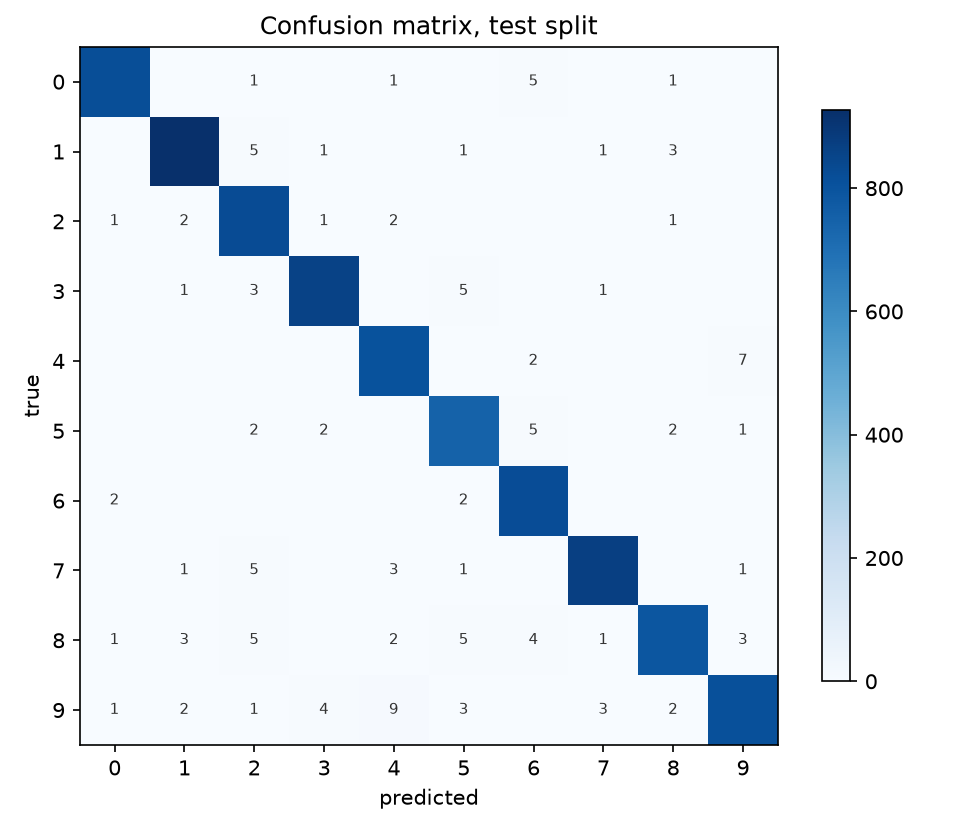

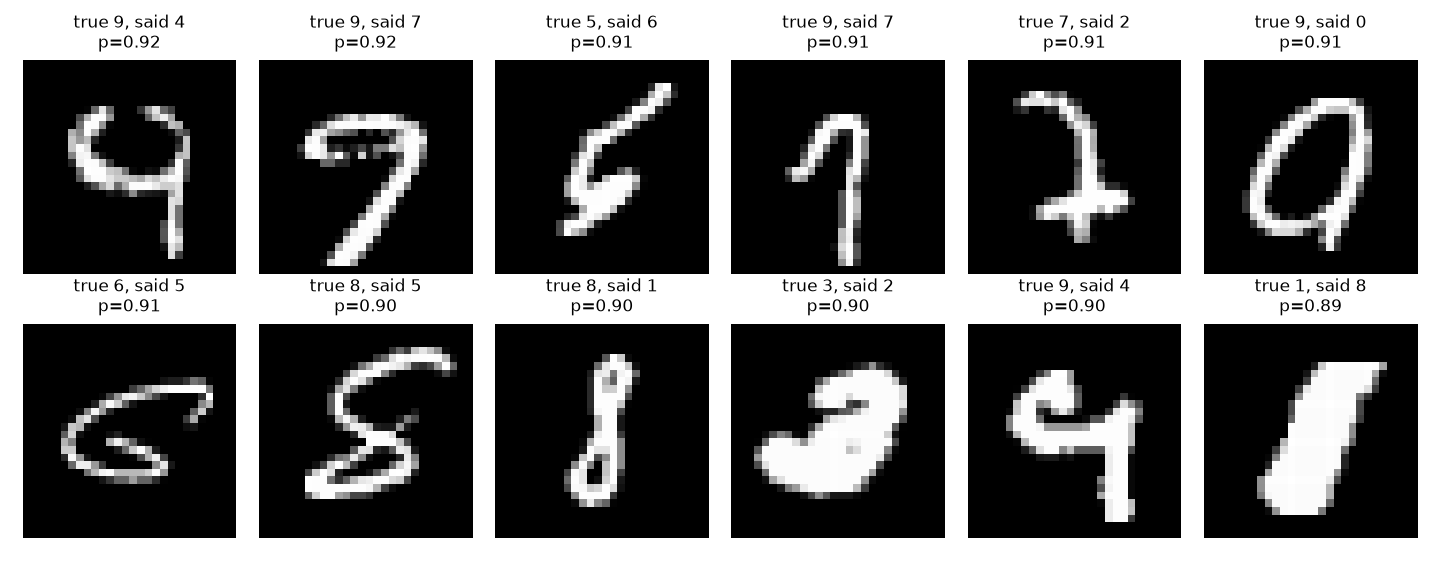

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(FIGURES / f'confusion_{RUN_NAME}.png')))
display(Image(filename=str(FIGURES / f'confident_mistakes_{RUN_NAME}.png')))

### Calibration

Expected calibration error bins the predictions by confidence and sums each
bin's gap between confidence and accuracy, weighted by how many predictions fall
there. It is reported beside the accuracy, since the two can disagree.

In [ ]:
payload['calibration']

,bin,n,mean_confidence,accuracy,gap
0,"[0.2, 0.3)",4,0.2782,0.2500,0.0282
1,"[0.3, 0.4)",27,0.3579,0.2222,0.1357
2,"[0.4, 0.5)",39,0.4505,0.5641,-0.1136
3,"[0.5, 0.6)",43,0.5474,0.6512,-0.1038
4,"[0.6, 0.7)",67,0.6524,0.6567,-0.0043
5,"[0.7, 0.8)",109,0.7506,0.8532,-0.1026
6,"[0.8, 0.9)",429,0.8702,0.9627,-0.0925
7,"[0.9, 1.0)",7682,0.9209,0.9987,-0.0778


## 7. The same model in PyTorch Lightning

The project is written in plain PyTorch so the training loop stays visible. The
epoch loop, gradient step, early-stopping check and gradient norms are all in
`src/training.py`.

`src/lightning_module.py` wraps the same `MLP`, the same loss and the same
optimizer. It is a wrapper rather than a second implementation, so both should
land in the same place.

In [ ]:
# Only this section needs Lightning, which the cloud images may not ship.
try:
    from src.lightning_module import train_with_lightning
except ModuleNotFoundError as error:
    print('Lightning is not installed:', error)
    print('On Kaggle: Settings > Internet on, then re-run the bootstrap cell.')
    lightning_metrics = None
else:
    lightning_metrics = train_with_lightning(final, CSV_PATH, accelerator='auto')

lightning_metrics

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Loading `train_dataloader` to estimate number of stepping batches.


/Users/bimladanu/Documents/Turing_College/Git_Projects_Turing_College/bidanu-NLP.AI.1.5/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/bimladanu/Documents/Turing_College/Git_Projects_Turing_College/bidanu-NLP.AI.1.5/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

  | Name  | Type | Params | Mode  | FLOPs
-----------------------------------------------
0 | model | MLP  | 1.2 M  | train | 0    
-----------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.796     Total estimated model params size (MB)
20        Modules in t

/Users/bimladanu/Documents/Turing_College/Git_Projects_Turing_College/bidanu-NLP.AI.1.5/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=150` reached.



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_accuracy          0.9815475940704346
        val_loss             0.54585862159729
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


{'val_loss': 0.54585862159729, 'val_accuracy': 0.9815475940704346}

## 8. Improvements beyond the baseline

Ensembling, test-time augmentation and a convolutional reference, each
measured on the same data, the same split and the same training loop.

### Ensembling and test-time augmentation

An ensemble averages probabilities rather than logits:

$$
\bar{p}(y \mid x) = \frac{1}{M} \sum_{m=1}^{M} p_m(y \mid x)
$$

The members differ only by seed.

Test-time augmentation applies the same averaging along another axis: one model,
several warped views of each image. The first view is always the unmodified
image.

In [ ]:
ensemble_config = ExperimentConfig(
    name="ensemble",
    data=data_config,
    model=final.model,
    train=replace(final.train, scheduler="cosine", max_epochs=ENSEMBLE_EPOCHS),
)
ENSEMBLE_SEEDS = [0, 1, 2]

members = train_ensemble(splits, ensemble_config, ENSEMBLE_SEEDS, verbose=True)
models = [result.model for result in members]

_, _, test_loader = make_loaders(splits, batch_size=ensemble_config.train.batch_size)

rows = [
    (f"member seed={seed}", accuracy(model_probabilities(model, test_loader, DEVICE), splits.y_test))
    for seed, model in zip(ENSEMBLE_SEEDS, models, strict=True)
]
rows.append(
    (f"ensemble of {len(models)}", accuracy(average_probabilities(models, test_loader, DEVICE), splits.y_test))
)
rows.append(
    ("TTA x4 (first member)", accuracy(tta_probabilities(models[0], test_loader, DEVICE, 4), splits.y_test))
)

pd.DataFrame(rows, columns=["model", "test accuracy"]).round(4)

seed 0: val accuracy 0.9832


seed 1: val accuracy 0.9833


seed 2: val accuracy 0.9821


,model,test accuracy
0,member seed=0,0.9848
1,member seed=1,0.9856
2,member seed=2,0.9846
3,ensemble of 3,0.9867
4,TTA x4 (first member),0.9837


### MLP versus a convolutional network

The model built here is an MLP. The largest improvement available is
architectural, so it is worth a number rather than an assertion.

Same data, same split, same loop, same epoch budget. Only the feature extractor
differs.

In [ ]:
cnn_result = train_cnn(splits, ensemble_config, ConvConfig(channels=(32, 64)), verbose=True)

comparison = pd.DataFrame(
    [
        {
            "model": f"MLP {list(final.model.hidden_sizes)}",
            "parameters": count_parameters(build_model(final.model)),
            "val accuracy": final_result.best_val_accuracy,
            "test accuracy": test_accuracy(final_result.model, splits, final.train),
            "seconds": round(final_result.total_seconds, 1),
        },
        {
            "model": "CNN 32-64",
            "parameters": cnn_result.n_parameters,
            "val accuracy": cnn_result.best_val_accuracy,
            "test accuracy": test_accuracy(cnn_result.model, splits, ensemble_config.train),
            "seconds": round(cnn_result.total_seconds, 1),
        },
    ]
)
comparison.round(4)

epoch   1  train loss 0.9368  acc 0.8604  |  val loss 0.6651  acc 0.9764


epoch   2  train loss 0.7617  acc 0.9352  |  val loss 0.6141  acc 0.9840


epoch   3  train loss 0.7351  acc 0.9472  |  val loss 0.6262  acc 0.9815


epoch   4  train loss 0.7214  acc 0.9529  |  val loss 0.6388  acc 0.9810


epoch   5  train loss 0.7145  acc 0.9548  |  val loss 0.6012  acc 0.9848


...

epoch  97  train loss 0.5734  acc 0.9901  |  val loss 0.5469  acc 0.9933


epoch  98  train loss 0.5730  acc 0.9894  |  val loss 0.5482  acc 0.9935


epoch  99  train loss 0.5741  acc 0.9888  |  val loss 0.5469  acc 0.9933


epoch 100  train loss 0.5730  acc 0.9885  |  val loss 0.5481  acc 0.9933


,model,parameters,val accuracy,test accuracy,seconds
0,"MLP [512, 512, 512, 512]",1199114,0.9843,0.9856,1229.9
1,CNN 32-64,421834,0.9938,0.9930,727.6


## 9. Limitations and further work

An MLP flattens the image, so neighbouring pixels carry unrelated weights and
translation invariance has to come from examples. Section 8 puts a number on
what that costs.

| Improvement | Status | Where |
|---|---|---|
| Learning-rate schedule (cosine, one-cycle, step) | swept | section 4, `--scheduler` |
| Data augmentation, shifts and rotations | swept | section 4, `src/augment.py` |
| Seed ensemble | measured | section 8 |
| Test-time augmentation | measured | section 8 |
| Label smoothing with tuned weight decay | swept | section 4 |
| A convolutional network | measured | section 8 |

Further work, in order of expected gain:

1. Elastic distortion on top of the shifts and rotations. It helped most in the
   original LeCun results, and the warp machinery is already in `src/augment.py`.
2. A joint search over the pairs a screening design cannot see together:
   learning rate with batch size, learning rate with optimizer. A small random
   search over those two planes costs less than the full sweep.
3. Temperature scaling fitted on validation. The ECE is measured but nothing is
   done about it.
4. A bootstrap confidence interval on the test accuracy, so two models can be
   compared with more than two numbers.
5. A CNN, which section 8 quantifies rather than assumes.

Read the two columns together. If the CNN reaches higher accuracy with fewer
parameters, the difference is the prior rather than the capacity.